# Impact of Financial Advertising Appeals on Retail Investors' Decision-Making
## BRM Assignment
### Data Analysis: Descriptive · Correlation · Regression · Reliability · Factor Analysis

---
## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

# ── Load data ──────────────────────────────────────────────────────────────────
df_raw = pd.read_excel('Financial_Survey_data.xlsx')
print(f'Dataset shape: {df_raw.shape}  ({df_raw.shape[0]} respondents, {df_raw.shape[1]} columns)')
df_raw.head(3)

Dataset shape: (143, 28)  (143 respondents, 28 columns)


,Age Group,Gender,Highest Educational Qualification,Monthly Income Level,Occupation,Investment Experience,Primary Investment Products Used,Bank advertisements that focus on family security influence me emotionally,"I feel more attracted to bank advertisements that show trust, stability, and safety",Emotional advertisements make me feel confident about investing in that bank,...,Bank advertisements appear honest and reliable,I believe that banks usually provide accurate information in their advertisements,A bank’s reputation increases the credibility of its advertisements,"If an advertisement seems misleading, I avoid investing in that bank","I understand the meaning of interest rates, returns, inflation, and risk",I can compare different investment options offered by banks,I can evaluate the risks involved before investing my money,I am confident in reading and understanding financial product terms,I actively seek financial knowledge before making investment decision,Emotional advertisements are more persuasive than rational advertisements
0,18-25,Female,Professional Qualification (CA/CFA/MBA etc.),"Below ₹25,000",Student,1–3 years,"Fixed Deposits, Mutual Funds, Insurance Plans,...",Agree,Neutral,Strongly Agree,...,Agree,Agree,Disagree,Strongly Agree,Disagree,Agree,Strongly Agree,Neutral,Agree,Strongly disagree
1,Below 18,Male,Doctorate,"Above ₹2,00,000",Student,3–5 years,"Fixed Deposits, Mutual Funds, Stocks/Equity, I...",Strongly Agree,Disagree,Agree,...,Strongly agree,Agree,Disagree,Strongly Disagree,Strongly agree,Agree,Neutral,Agree,Agree,Neutral
2,Below 18,Male,Postgraduate,"25,000 – 50,000",Salaried Employee,Less than 1 year,"Fixed Deposits, Mutual Funds, Bonds, Digital Gold",Neutral,Strongly Agree,Agree,...,Neutral,Neutral,Strongly disagree,Neutral,Strongly agree,Agree,Neutral,Strongly agree,Disagree,Disagree


In [2]:
# ── Short column names for readability ─────────────────────────────────────────
col_map = {
    'Age Group': 'Age',
    ' Gender': 'Gender',
    'Highest Educational Qualification': 'Education',
    'Monthly Income Level': 'Income',
    'Occupation': 'Occupation',
    'Investment Experience': 'InvExp',
    'Primary Investment Products Used': 'Products',
    # Emotional Appeal (EA)
    'Bank advertisements that focus on family security influence me emotionally': 'EA1',
    'I feel more attracted to bank advertisements that show trust, stability, and safety': 'EA2',
    'Emotional advertisements make me feel confident about investing in that bank': 'EA3',
    'Advertisements that highlight a better future and peace of mind motivate me to invest': 'EA4',
    'I tend to remember advertisements that create an emotional connection': 'EA5',
    # Rational Appeal (RA)
    'I prefer bank advertisements that provide factual and numerical information': 'RA1',
    'Advertisements showing interest rates and returns influence my investment decision': 'RA2',
    'I trust advertisements more when they include data, charts, or comparisons': 'RA3',
    'I find rational advertisements more useful than emotional advertisements while investing': 'RA4',
    'I am more likely to invest when an advertisement clearly explains product benefits': 'RA5',
    # Financial Trust (FT)
    'I trust financial advertisements from reputed banks': 'FT1',
    'Bank advertisements appear honest and reliable': 'FT2',
    'I believe that banks usually provide accurate information in their advertisements': 'FT3',
    'A bank\u2019s reputation increases the credibility of its advertisements': 'FT4',
    'If an advertisement seems misleading, I avoid investing in that bank': 'FT5',
    # Financial Literacy (FL)
    'I understand the meaning of interest rates, returns, inflation, and risk': 'FL1',
    'I can compare different investment options offered by banks': 'FL2',
    'I can evaluate the risks involved before investing my money': 'FL3',
    'I am confident in reading and understanding financial product terms': 'FL4',
    'I actively seek financial knowledge before making investment decision': 'FL5',
    # Investment Decision (ID) — single item
    'Emotional advertisements are more persuasive than rational advertisements': 'ID1',
}
df = df_raw.rename(columns=col_map)

# ── Encode Likert text → numeric 1-5 ──────────────────────────────────────────
likert_map = {
    'Strongly Disagree': 1, 'Strongly disagree': 1,
    'Disagree': 2,
    'Neutral': 3,
    'Agree': 4,
    'Strongly Agree': 5, 'Strongly agree': 5,
}
likert_cols = [c for c in df.columns if c.startswith(('EA','RA','FT','FL','ID'))]
for c in likert_cols:
    df[c] = df[c].map(likert_map)

print('Likert columns encoded:', likert_cols)
print('Missing values after encoding:\n', df[likert_cols].isnull().sum())

Likert columns encoded: ['EA1', 'EA2', 'EA3', 'EA4', 'EA5', 'RA1', 'RA2', 'RA3', 'RA4', 'RA5', 'FT1', 'FT2', 'FT3', 'FT4', 'FT5', 'FL1', 'FL2', 'FL3', 'FL4', 'FL5', 'ID1']
Missing values after encoding:
 EA1    0
EA2    0
EA3    0
EA4    0
EA5    0
RA1    0
RA2    0
RA3    0
RA4    0
RA5    0
FT1    0
FT2    0
FT3    0
FT4    0
FT5    0
FL1    0
FL2    0
FL3    0
FL4    0
FL5    0
ID1    0
dtype: int64


---
## 1. Descriptive Statistics

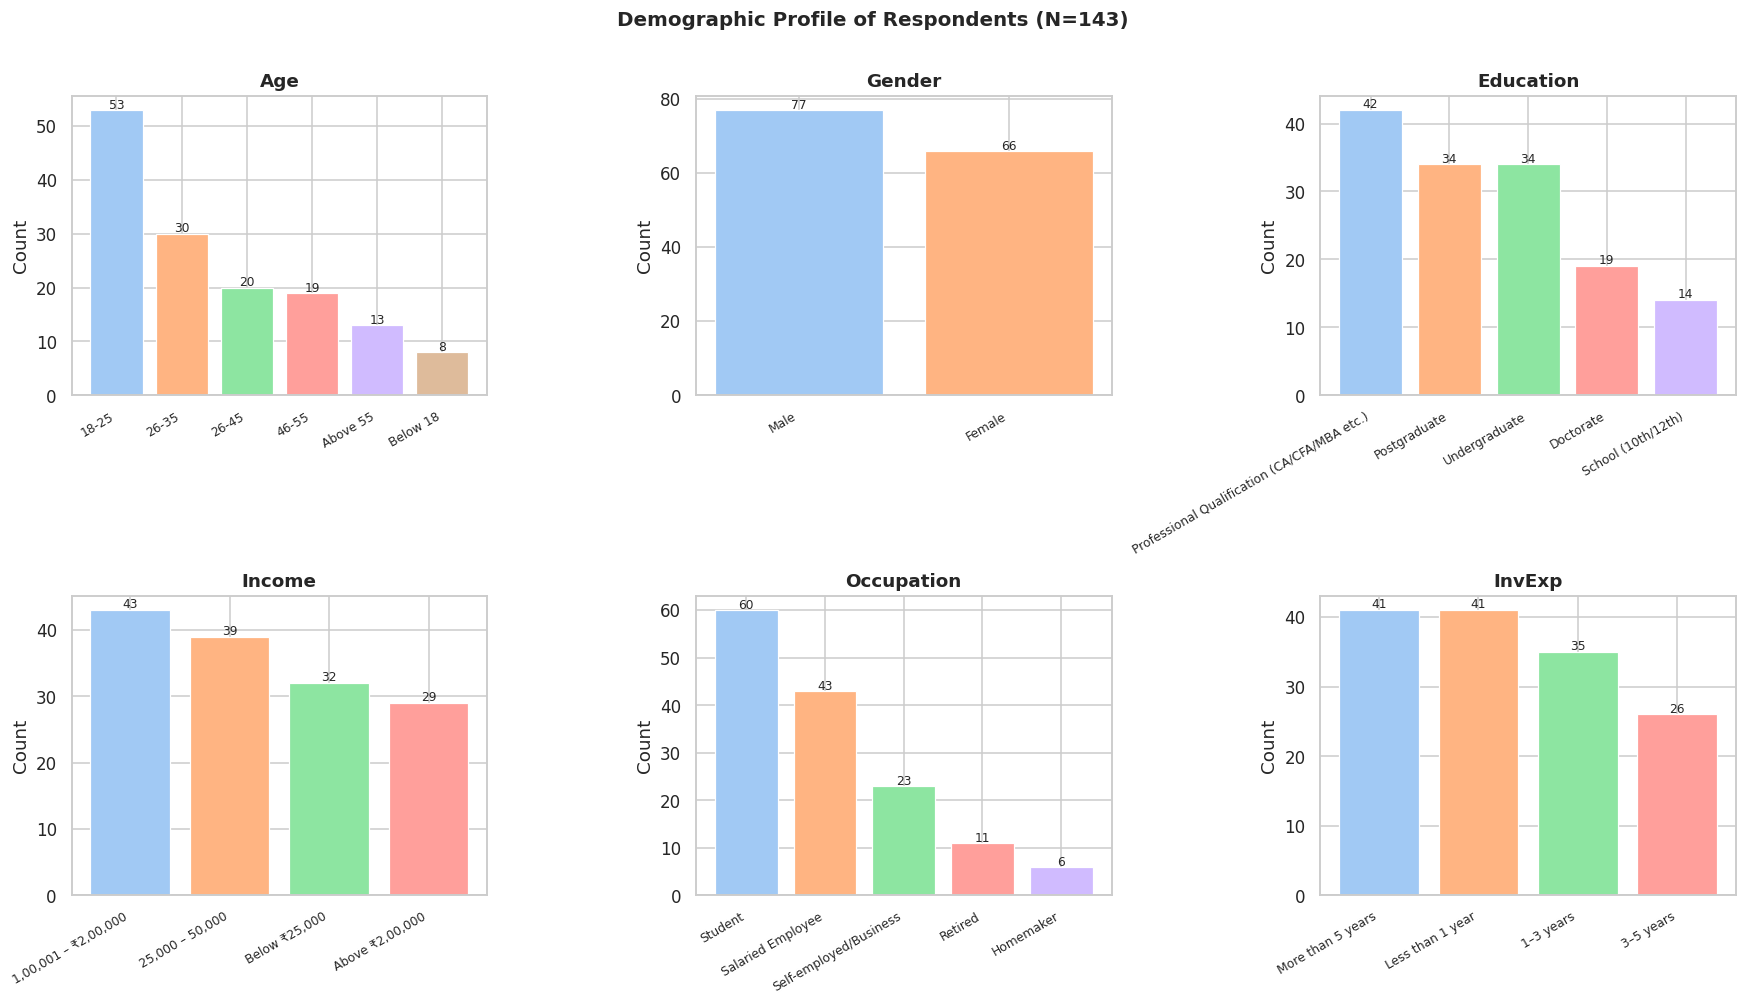

In [3]:
# ── 1a. Demographic Profile ────────────────────────────────────────────────────
demo_cols = ['Age', 'Gender', 'Education', 'Income', 'Occupation', 'InvExp']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = sns.color_palette('pastel', 10)

for i, col in enumerate(demo_cols):
    vc = df[col].value_counts()
    axes[i].bar(range(len(vc)), vc.values, color=colors[:len(vc)], edgecolor='white', linewidth=0.8)
    axes[i].set_xticks(range(len(vc)))
    axes[i].set_xticklabels([str(x) for x in vc.index], rotation=30, ha='right', fontsize=8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Count')
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + 0.3, str(v), ha='center', fontsize=8)

plt.suptitle('Demographic Profile of Respondents (N=143)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [4]:
# ── 1b. Descriptive stats for Likert constructs ────────────────────────────────
desc = df[likert_cols].describe().T
desc['skewness'] = df[likert_cols].skew()
desc['kurtosis'] = df[likert_cols].kurtosis()
desc = desc[['count','mean','std','min','25%','50%','75%','max','skewness','kurtosis']].round(3)

# Tag constructs
def tag(c):
    return {'EA':'Emotional Appeal','RA':'Rational Appeal',
            'FT':'Financial Trust','FL':'Financial Literacy','ID':'Investment Decision'}[c[:2]]
desc.index = pd.MultiIndex.from_tuples([(tag(c), c) for c in desc.index], names=['Construct','Item'])
print('\n=== Descriptive Statistics — Likert Scale Items ===')
desc


=== Descriptive Statistics — Likert Scale Items ===


count   mean    std  min  25%  50%  75%  max  \
Construct           Item                                                 
Emotional Appeal    EA1   143.0  3.580  1.165  1.0  3.0  4.0  4.0  5.0   
                    EA2   143.0  3.517  1.209  1.0  3.0  4.0  4.0  5.0   
                    EA3   143.0  3.573  1.141  1.0  3.0  4.0  4.0  5.0   
                    EA4   143.0  3.350  1.152  1.0  3.0  3.0  4.0  5.0   
                    EA5   143.0  3.448  1.161  1.0  3.0  4.0  4.0  5.0   
Rational Appeal     RA1   143.0  3.420  1.177  1.0  2.5  4.0  4.0  5.0   
                    RA2   143.0  3.657  1.120  1.0  3.0  4.0  4.0  5.0   
                    RA3   143.0  3.741  1.137  1.0  3.0  4.0  5.0  5.0   
                    RA4   143.0  3.678  1.225  1.0  3.0  4.0  5.0  5.0   
                    RA5   143.0  3.748  1.110  1.0  3.0  4.0  5.0  5.0   
Financial Trust     FT1   143.0  3.636  1.038  1.0  3.0  4.0  4.0  5.0   
                    FT2   143.0  3.517  1.047  1.0  3.0  4.0  4.0  5.0   
                    FT3   143.0  3.294  1.093  1.0  3.0  3.0  4.0  5.0   
                    FT4   143.0  3.399  1.069  1.0  3.0  4.0  4.0  5.0   
                    FT5   143.0  3.601  1.127  1.0  3.0  4.0  4.0  5.0   
Financial Literacy  FL1   143.0  3.888  1.175  1.0  3.0  4.0  5.0  5.0   
                    FL2   143.0  3.755  1.083  1.0  3.0  4.0  5.0  5.0   
                    FL3   143.0  3.979  1.097  1.0  3.0  4.0  5.0  5.0   
                    FL4   143.0  3.671  1.143  1.0  3.0  4.0  5.0  5.0   
                    FL5   143.0  3.643  1.064  1.0  3.0  4.0  4.0  5.0   
Investment Decision ID1   143.0  2.734  1.305  1.0  2.0  3.0  4.0  5.0   

                          skewness  kurtosis  
Construct           Item                      
Emotional Appeal    EA1     -0.617    -0.354  
                    EA2     -0.477    -0.706  
                    EA3     -0.601    -0.334  
                    EA4     -0.354    -0.598  
                    EA5     -0.474    -0.483  
Rational Appeal     RA1     -0.316    -0.866  
                    RA2     -0.691    -0.149  
                    RA3     -0.701    -0.346  
                    RA4     -0.829    -0.173  
                    RA5     -0.740    -0.168  
Financial Trust     FT1     -0.486    -0.503  
                    FT2     -0.607     0.036  
                    FT3     -0.345    -0.475  
                    FT4     -0.468    -0.238  
                    FT5     -0.571    -0.324  
Financial Literacy  FL1     -1.046     0.278  
                    FL2     -0.814     0.192  
                    FL3     -1.029     0.457  
                    FL4     -0.731    -0.130  
                    FL5     -0.595    -0.277  
Investment Decision ID1      0.236    -1.032

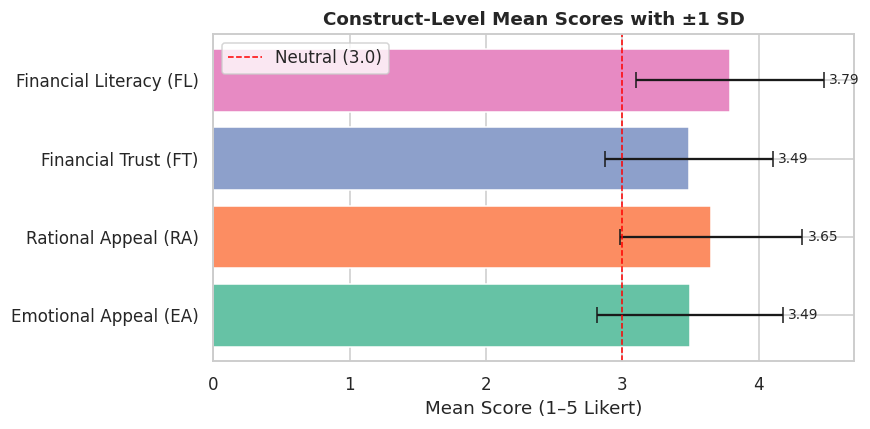

                          Mean     SD  Min  Max
Emotional Appeal (EA)    3.494  0.683  1.0  5.0
Rational Appeal (RA)     3.649  0.668  1.0  5.0
Financial Trust (FT)     3.490  0.614  1.0  5.0
Financial Literacy (FL)  3.787  0.688  1.0  5.0


In [5]:
# ── 1c. Construct-level mean scores ───────────────────────────────────────────
constructs = {
    'Emotional Appeal (EA)': [c for c in likert_cols if c.startswith('EA')],
    'Rational Appeal (RA)':  [c for c in likert_cols if c.startswith('RA')],
    'Financial Trust (FT)':  [c for c in likert_cols if c.startswith('FT')],
    'Financial Literacy (FL)': [c for c in likert_cols if c.startswith('FL')],
}
for name, items in constructs.items():
    df[name] = df[items].mean(axis=1)

construct_scores = pd.DataFrame({
    'Mean':  {k: df[k].mean() for k in constructs},
    'SD':    {k: df[k].std()  for k in constructs},
    'Min':   {k: df[k].min()  for k in constructs},
    'Max':   {k: df[k].max()  for k in constructs},
}).round(3)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(list(constructs.keys()), construct_scores['Mean'],
               xerr=construct_scores['SD'], capsize=5,
               color=sns.color_palette('Set2', 4), edgecolor='white')
ax.axvline(3, color='red', linestyle='--', linewidth=1, label='Neutral (3.0)')
ax.set_xlabel('Mean Score (1–5 Likert)')
ax.set_title('Construct-Level Mean Scores with ±1 SD', fontweight='bold')
ax.legend()
for i, (m, s) in enumerate(zip(construct_scores['Mean'], construct_scores['SD'])):
    ax.text(m + s + 0.04, i, f'{m:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print(construct_scores)

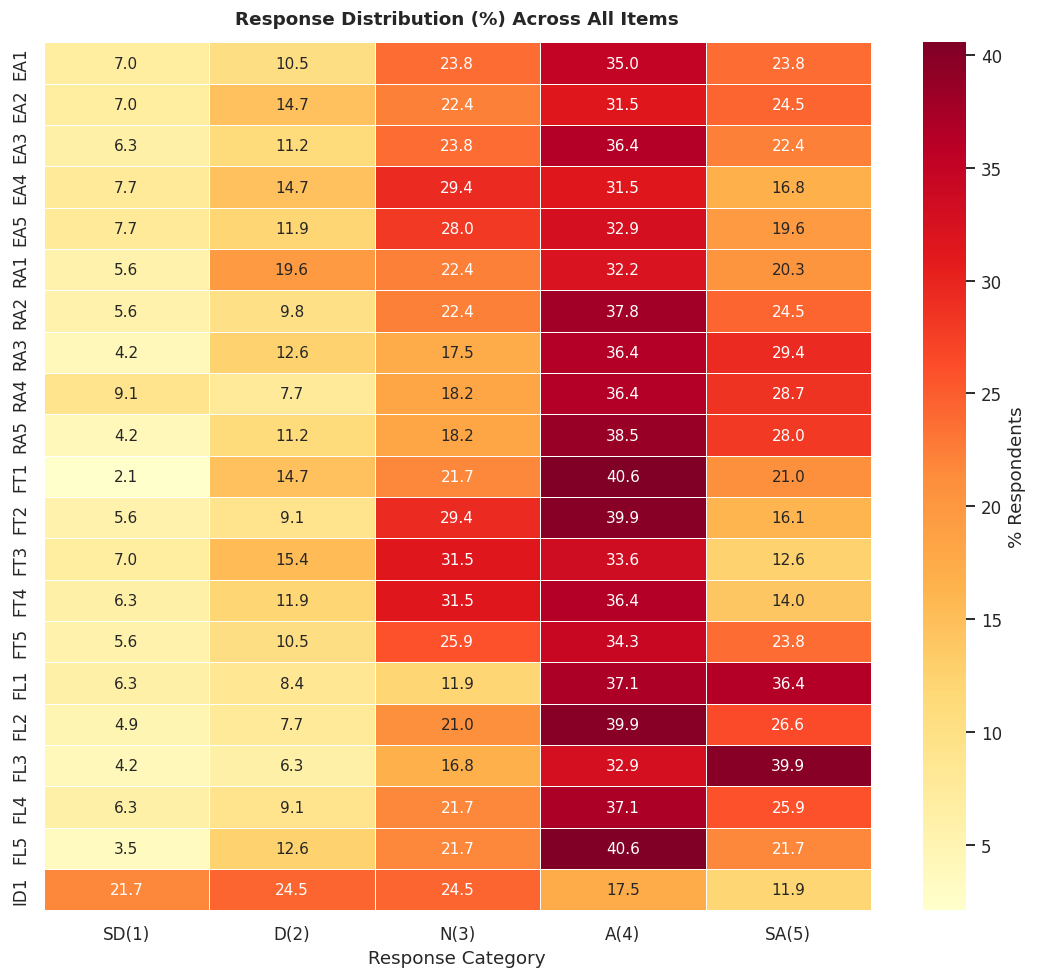

In [6]:
# ── 1d. Response distribution heatmap ─────────────────────────────────────────
likert_labels = ['SD(1)', 'D(2)', 'N(3)', 'A(4)', 'SA(5)']
dist_pct = pd.DataFrame(index=likert_cols)
for val, lab in zip([1,2,3,4,5], likert_labels):
    dist_pct[lab] = [(df[c] == val).sum() / len(df) * 100 for c in likert_cols]

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(dist_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% Respondents'})
ax.set_title('Response Distribution (%) Across All Items', fontweight='bold', pad=12)
ax.set_xlabel('Response Category')
plt.tight_layout()
plt.show()

---
## 2. Reliability Analysis (Cronbach's Alpha)

In [7]:
def cronbach_alpha(data):
    """Compute Cronbach's Alpha for a DataFrame of items."""
    data = data.dropna()
    k = data.shape[1]
    var_items = data.var(axis=0, ddof=1).sum()
    var_total = data.sum(axis=1).var(ddof=1)
    alpha = (k / (k - 1)) * (1 - var_items / var_total)
    return round(alpha, 4)

def item_total_corr(data):
    """Item-total correlations (corrected)."""
    result = {}
    total = data.sum(axis=1)
    for col in data.columns:
        corrected_total = total - data[col]
        r, p = stats.pearsonr(data[col].dropna(), corrected_total[data[col].notna()])
        result[col] = {'Corrected Item-Total r': round(r, 3), 'p-value': round(p, 4)}
    return pd.DataFrame(result).T

print('=' * 55)
print('  RELIABILITY ANALYSIS — Cronbach\'s Alpha')
print('=' * 55)
construct_items = {
    'Emotional Appeal': [c for c in likert_cols if c.startswith('EA')],
    'Rational Appeal':  [c for c in likert_cols if c.startswith('RA')],
    'Financial Trust':  [c for c in likert_cols if c.startswith('FT')],
    'Financial Literacy': [c for c in likert_cols if c.startswith('FL')],
}

alpha_results = {}
for name, items in construct_items.items():
    a = cronbach_alpha(df[items])
    note = '✓ Acceptable' if a >= 0.70 else ('✓ Good' if a >= 0.80 else '✗ Borderline')
    alpha_results[name] = a
    print(f'\n{name} (N items = {len(items)})')
    print(f'  Cronbach\'s Alpha = {a}  [{note}]')
    print(item_total_corr(df[items]).to_string())

  RELIABILITY ANALYSIS — Cronbach's Alpha

Emotional Appeal (N items = 5)
  Cronbach's Alpha = 0.522  [✗ Borderline]
     Corrected Item-Total r  p-value
EA1                   0.273   0.0010
EA2                   0.254   0.0022
EA3                   0.278   0.0008
EA4                   0.329   0.0001
EA5                   0.314   0.0001

Rational Appeal (N items = 5)
  Cronbach's Alpha = 0.5041  [✗ Borderline]
     Corrected Item-Total r  p-value
RA1                   0.197   0.0186
RA2                   0.299   0.0003
RA3                   0.295   0.0003
RA4                   0.318   0.0001
RA5                   0.272   0.0010

Financial Trust (N items = 5)
  Cronbach's Alpha = 0.4826  [✗ Borderline]
     Corrected Item-Total r  p-value
FT1                   0.270   0.0011
FT2                   0.299   0.0003
FT3                   0.211   0.0116
FT4                   0.246   0.0030
FT5                   0.274   0.0009

Financial Literacy (N items = 5)
  Cronbach's Alpha = 0.5954  [✗ B

Overall Cronbach's Alpha (all 20 scale items): 0.6944


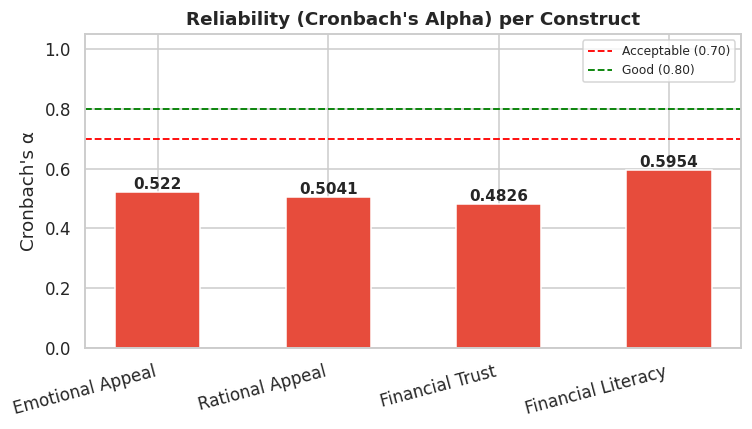

In [8]:
# ── Overall alpha across all scale items ──────────────────────────────────────
all_scale_items = [c for c in likert_cols if not c.startswith('ID')]
overall_alpha = cronbach_alpha(df[all_scale_items])
print(f'Overall Cronbach\'s Alpha (all 20 scale items): {overall_alpha}')

# Visualise alphas
fig, ax = plt.subplots(figsize=(7, 4))
names = list(alpha_results.keys())
vals  = list(alpha_results.values())
colors_bar = ['#2ecc71' if v >= 0.80 else '#f39c12' if v >= 0.70 else '#e74c3c' for v in vals]
bars = ax.bar(names, vals, color=colors_bar, edgecolor='white', width=0.5)
ax.axhline(0.70, color='red',    linestyle='--', linewidth=1.2, label='Acceptable (0.70)')
ax.axhline(0.80, color='green',  linestyle='--', linewidth=1.2, label='Good (0.80)')
ax.set_ylim(0, 1.05)
ax.set_ylabel("Cronbach's α")
ax.set_title("Reliability (Cronbach's Alpha) per Construct", fontweight='bold')
ax.legend(fontsize=8)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, str(v), ha='center', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

---
## 3. Correlation Analysis

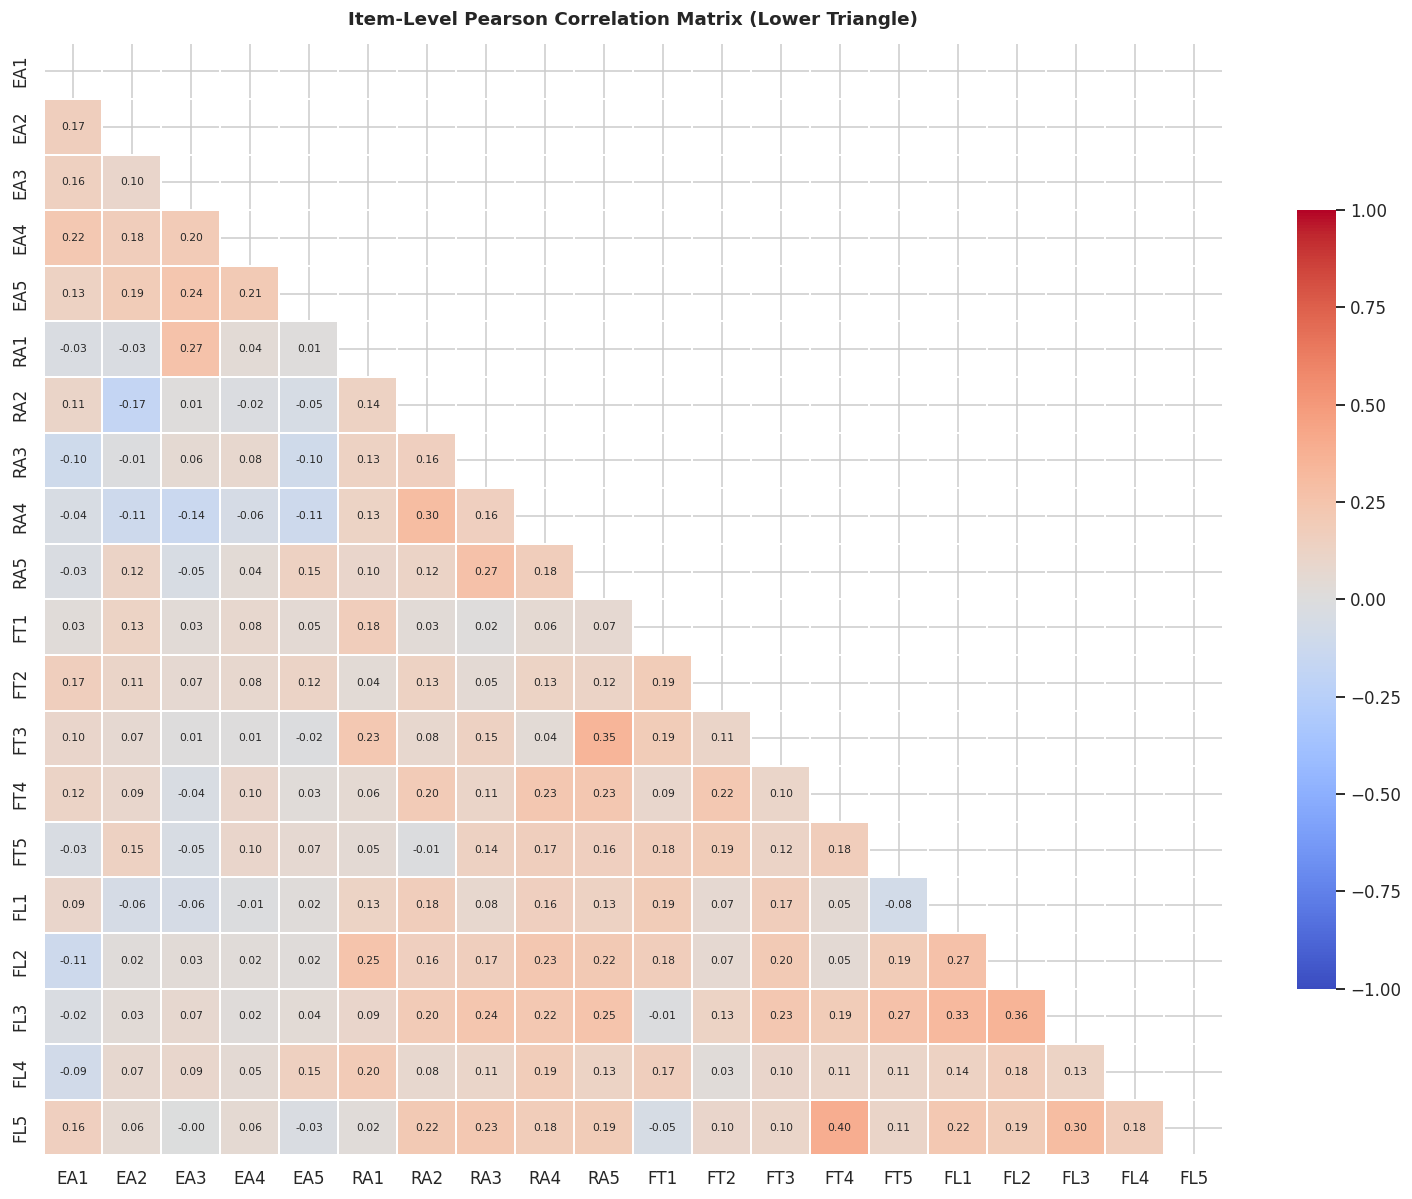

In [9]:
# ── 3a. Item-level correlation matrix ─────────────────────────────────────────
corr_items = df[all_scale_items].corr()

# Significance mask
n = len(df)
p_matrix = pd.DataFrame(index=corr_items.index, columns=corr_items.columns, dtype=float)
for r in corr_items.index:
    for c in corr_items.columns:
        rho = corr_items.loc[r, c]
        t_stat = rho * np.sqrt(n - 2) / np.sqrt(1 - rho**2 + 1e-10)
        p_matrix.loc[r, c] = 2 * stats.t.sf(abs(t_stat), df=n-2)

mask = np.triu(np.ones_like(corr_items, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_items, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.3,
            ax=ax, cbar_kws={'shrink': 0.7},
            annot_kws={'size': 7})
ax.set_title('Item-Level Pearson Correlation Matrix (Lower Triangle)', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


=== Construct-Level Correlation Matrix ===
                         Emotional Appeal (EA)  Rational Appeal (RA)  \
Emotional Appeal (EA)                    1.000                -0.026   
Rational Appeal (RA)                    -0.026                 1.000   
Financial Trust (FT)                     0.187                 0.365   
Financial Literacy (FL)                  0.070                 0.474   

                         Financial Trust (FT)  Financial Literacy (FL)  
Emotional Appeal (EA)                   0.187                    0.070  
Rational Appeal (RA)                    0.365                    0.474  
Financial Trust (FT)                    1.000                    0.346  
Financial Literacy (FL)                 0.346                    1.000  

=== p-values ===
                         Emotional Appeal (EA)  Rational Appeal (RA)  \
Emotional Appeal (EA)                   0.0000                0.7566   
Rational Appeal (RA)                    0.7566                0.0000

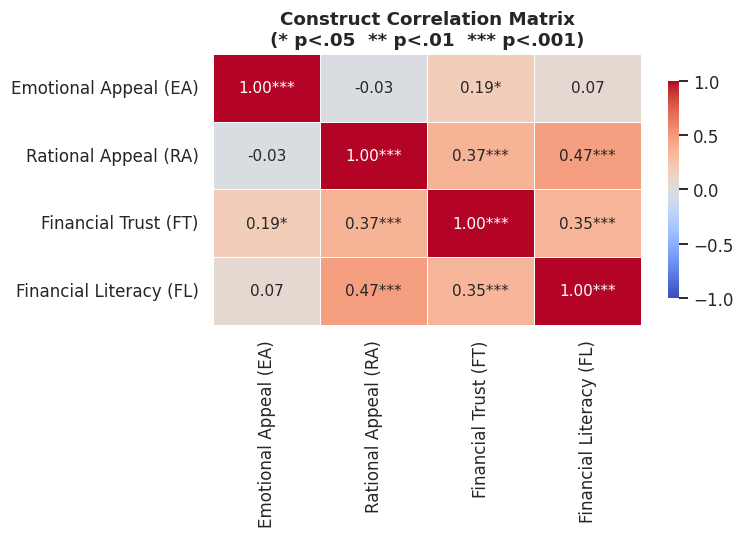

In [10]:
# ── 3b. Construct-level correlation with significance ─────────────────────────
construct_score_cols = list(constructs.keys())
corr_c = df[construct_score_cols].corr()

# Compute p-values
p_c = pd.DataFrame(index=corr_c.index, columns=corr_c.columns, dtype=float)
for r in corr_c.index:
    for c in corr_c.columns:
        rho = corr_c.loc[r, c]
        t_stat = rho * np.sqrt(n - 2) / np.sqrt(1 - rho**2 + 1e-10)
        p_c.loc[r, c] = 2 * stats.t.sf(abs(t_stat), df=n-2)

print('\n=== Construct-Level Correlation Matrix ===')
print(corr_c.round(3))
print('\n=== p-values ===')
print(p_c.round(4))

fig, ax = plt.subplots(figsize=(7, 5))
# Annotate with r and significance stars
annot = pd.DataFrame(index=corr_c.index, columns=corr_c.columns)
for r in corr_c.index:
    for c in corr_c.columns:
        rv = corr_c.loc[r,c]; pv = float(p_c.loc[r,c])
        star = '***' if pv<0.001 else ('**' if pv<0.01 else ('*' if pv<0.05 else ''))
        annot.loc[r,c] = f'{rv:.2f}{star}'

sns.heatmap(corr_c.astype(float), annot=annot, fmt='', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 10}, cbar_kws={'shrink': 0.8})
ax.set_title('Construct Correlation Matrix\n(* p<.05  ** p<.01  *** p<.001)', fontweight='bold')
plt.tight_layout()
plt.show()

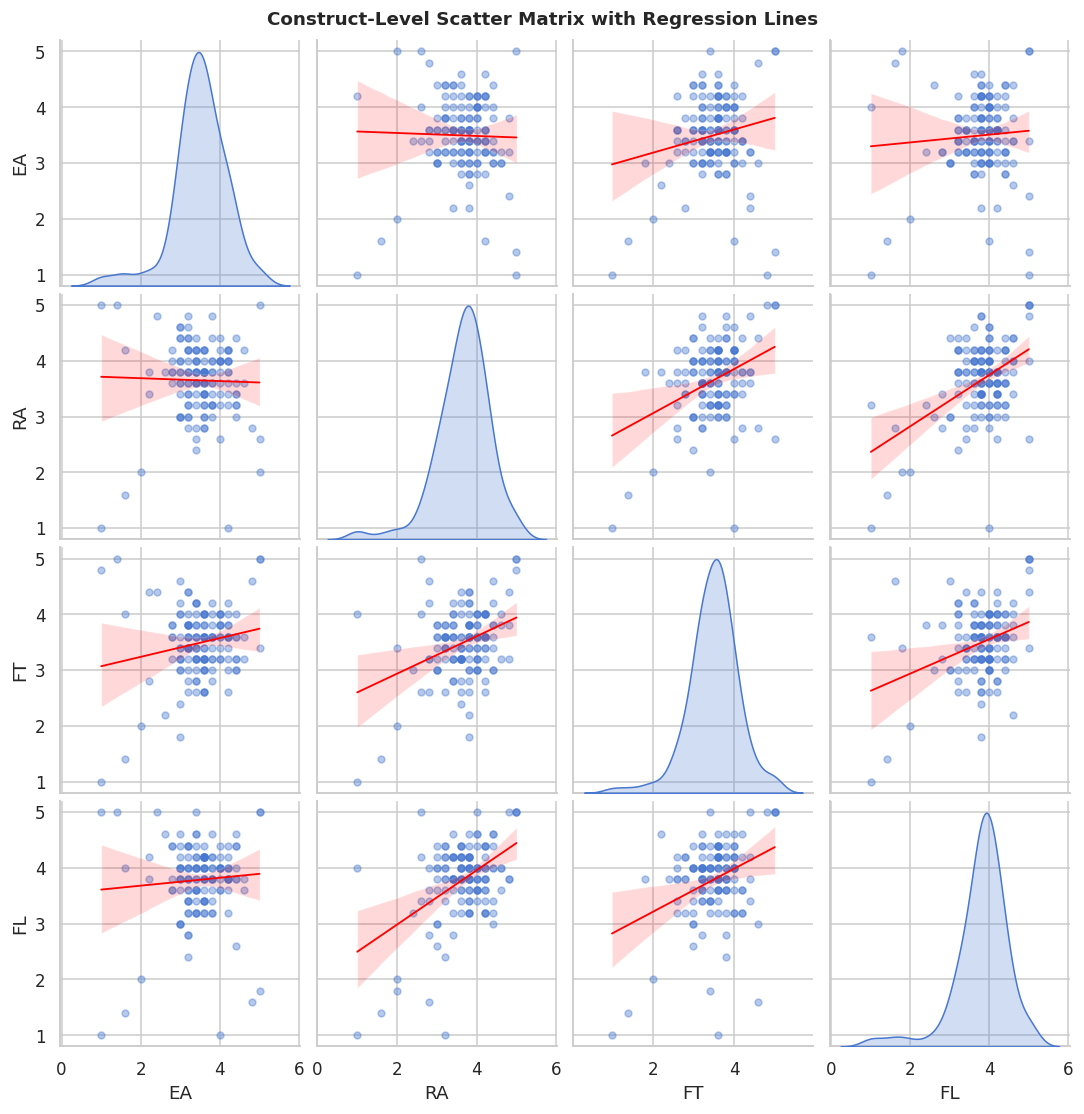

In [11]:
# ── 3c. Scatter matrix (pairplot) ─────────────────────────────────────────────
short_names = {'Emotional Appeal (EA)':'EA','Rational Appeal (RA)':'RA',
               'Financial Trust (FT)':'FT','Financial Literacy (FL)':'FL'}
plot_df = df[construct_score_cols].rename(columns=short_names)

g = sns.pairplot(plot_df, kind='reg', diag_kind='kde',
                 plot_kws={'line_kws':{'color':'red','linewidth':1.2},
                           'scatter_kws':{'alpha':0.4, 's':20}})
g.figure.suptitle('Construct-Level Scatter Matrix with Regression Lines', y=1.01, fontweight='bold')
plt.show()

---
## 4. Regression Analysis

In [12]:
from scipy.stats import t as t_dist

def ols_summary(X_df, y_series, title=''):
    """Manual OLS with full summary table."""
    X = np.column_stack([np.ones(len(X_df))] + [X_df[c] for c in X_df.columns])
    y = y_series.values
    mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
    X, y = X[mask], y[mask]
    n, k = X.shape

    betas = np.linalg.lstsq(X, y, rcond=None)[0]
    y_hat = X @ betas
    resid = y - y_hat
    ss_res = resid @ resid
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2  = 1 - ss_res / ss_tot
    r2a = 1 - (1 - r2) * (n - 1) / (n - k)
    mse = ss_res / (n - k)
    var_b = mse * np.linalg.inv(X.T @ X).diagonal()
    se_b  = np.sqrt(var_b)
    t_vals = betas / se_b
    p_vals = 2 * t_dist.sf(np.abs(t_vals), df=n - k)
    f_stat = (r2 / (k - 1)) / ((1 - r2) / (n - k))
    f_pval = stats.f.sf(f_stat, k - 1, n - k)

    names = ['Intercept'] + list(X_df.columns)
    res_df = pd.DataFrame({'Beta': betas, 'SE': se_b, 't': t_vals, 'p': p_vals}, index=names).round(4)
    res_df['Sig'] = res_df['p'].apply(lambda p: '***' if p<.001 else ('**' if p<.01 else ('*' if p<.05 else '')))

    print(f'\n{"═"*60}')
    print(f' {title}')
    print(f'{"═"*60}')
    print(f' n={n}  R²={r2:.4f}  Adj-R²={r2a:.4f}  F({k-1},{n-k})={f_stat:.3f}  p={f_pval:.4f}')
    print(f'{"─"*60}')
    print(res_df.to_string())
    return res_df, r2, r2a, f_stat, f_pval

EA_col = 'Emotional Appeal (EA)'
RA_col = 'Rational Appeal (RA)'
FT_col = 'Financial Trust (FT)'
FL_col = 'Financial Literacy (FL)'
ID_col = 'ID1'

# Model 1: EA & RA → ID
r1, r2_1, r2a_1, f1, fp1 = ols_summary(df[[EA_col, RA_col]], df[ID_col],
    'Model 1: Emotional & Rational Appeal → Investment Decision')

# Model 2: FT added (mediation path)
r2m, r2_2, r2a_2, f2, fp2 = ols_summary(df[[EA_col, RA_col, FT_col]], df[ID_col],
    'Model 2: + Financial Trust (Mediation Test)')

# Model 3: FL added (moderation proxy)
r3, r2_3, r2a_3, f3, fp3 = ols_summary(df[[EA_col, RA_col, FT_col, FL_col]], df[ID_col],
    'Model 3: + Financial Literacy (Full Model)')


════════════════════════════════════════════════════════════
 Model 1: Emotional & Rational Appeal → Investment Decision
════════════════════════════════════════════════════════════
 n=143  R²=0.0921  Adj-R²=0.0791  F(2,140)=7.101  p=0.0012
────────────────────────────────────────────────────────────
                         Beta      SE       t       p  Sig
Intercept              3.4141  0.8034  4.2495  0.0000  ***
Emotional Appeal (EA)  0.3157  0.1539  2.0517  0.0421    *
Rational Appeal (RA)  -0.4886  0.1573 -3.1064  0.0023   **

════════════════════════════════════════════════════════════
 Model 2: + Financial Trust (Mediation Test)
════════════════════════════════════════════════════════════
 n=143  R²=0.0923  Adj-R²=0.0727  F(3,139)=4.712  p=0.0037
────────────────────────────────────────────────────────────
                         Beta      SE       t       p  Sig
Intercept              3.4700  0.8629  4.0211  0.0001  ***
Emotional Appeal (EA)  0.3218  0.1580  2.0367  0.0436  

In [13]:
# ── 4b. Mediation path: EA/RA → FT ────────────────────────────────────────────
r_med, _, _, _, _ = ols_summary(df[[EA_col, RA_col]], df[FT_col],
    'Mediation Path: Emotional & Rational Appeal → Financial Trust')

# ── 4c. Moderation: EA × FL → FT ──────────────────────────────────────────────
df['EA_z'] = (df[EA_col] - df[EA_col].mean()) / df[EA_col].std()
df['FL_z'] = (df[FL_col] - df[FL_col].mean()) / df[FL_col].std()
df['EA_x_FL'] = df['EA_z'] * df['FL_z']
r_mod, _, _, _, _ = ols_summary(df[['EA_z', 'FL_z', 'EA_x_FL']], df[FT_col],
    'Moderation: EA × FL Interaction → Financial Trust')


════════════════════════════════════════════════════════════
 Mediation Path: Emotional & Rational Appeal → Financial Trust
════════════════════════════════════════════════════════════
 n=143  R²=0.1724  Adj-R²=0.1606  F(2,140)=14.580  p=0.0000
────────────────────────────────────────────────────────────
                         Beta      SE       t       p  Sig
Intercept              1.6293  0.3607  4.5169  0.0000  ***
Emotional Appeal (EA)  0.1770  0.0691  2.5625  0.0114    *
Rational Appeal (RA)   0.3403  0.0706  4.8187  0.0000  ***

════════════════════════════════════════════════════════════
 Moderation: EA × FL Interaction → Financial Trust
════════════════════════════════════════════════════════════
 n=143  R²=0.2740  Adj-R²=0.2583  F(3,139)=17.487  p=0.0000
────────────────────────────────────────────────────────────
             Beta      SE        t       p  Sig
Intercept  3.4975  0.0442  79.0726  0.0000  ***
EA_z       0.0666  0.0450   1.4805  0.1410     
FL_z       0.1487 

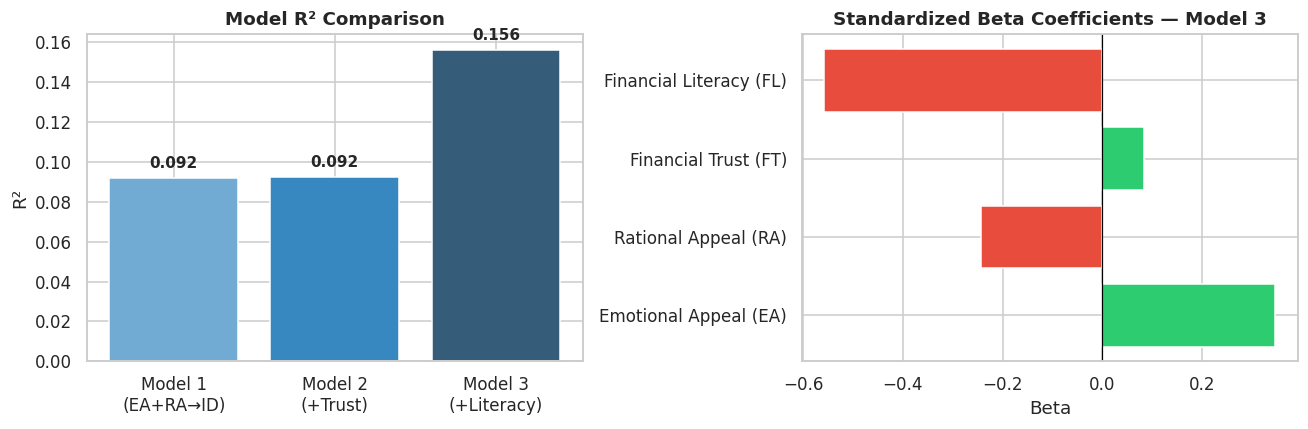

In [14]:
# ── 4d. Coefficient comparison chart ──────────────────────────────────────────
model_labels = ['Model 1\n(EA+RA→ID)', 'Model 2\n(+Trust)', 'Model 3\n(+Literacy)']
r2_vals = [r2_1, r2_2, r2_3]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# R² comparison
axes[0].bar(model_labels, r2_vals, color=sns.color_palette('Blues_d', 3), edgecolor='white')
axes[0].set_ylabel('R²')
axes[0].set_title('Model R² Comparison', fontweight='bold')
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

# Beta coefficients — Model 3
betas_m3 = r3['Beta'].iloc[1:]  # drop intercept
colors_m3 = ['#2ecc71' if b > 0 else '#e74c3c' for b in betas_m3]
axes[1].barh(betas_m3.index, betas_m3.values, color=colors_m3, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Standardized Beta Coefficients — Model 3', fontweight='bold')
axes[1].set_xlabel('Beta')
plt.tight_layout()
plt.show()

---
## 5. Factor Analysis (PCA-based Exploratory)

In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

fa_data = df[all_scale_items].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(fa_data)

# ── Bartlett's sphericity (approx) & KMO ─────────────────────────────────────
R = np.corrcoef(X_scaled.T)
n_obs, p = X_scaled.shape
chi2_bart = -(n_obs - 1 - (2*p + 5)/6) * np.log(np.linalg.det(R))
df_bart = p * (p - 1) / 2
p_bart = stats.chi2.sf(chi2_bart, df=df_bart)
print(f'Bartlett\'s Test of Sphericity: χ²({int(df_bart)}) = {chi2_bart:.2f},  p = {p_bart:.4e}')
print('→ Significant: Factor analysis is appropriate.' if p_bart < 0.05 else '→ Not significant.')

# ── KMO (Kaiser-Meyer-Olkin) ──────────────────────────────────────────────────
R_inv = np.linalg.inv(R)
P = np.zeros_like(R)
for i in range(p):
    for j in range(p):
        if i != j:
            P[i, j] = -R_inv[i, j] / np.sqrt(R_inv[i, i] * R_inv[j, j])
r2_sum  = np.sum(R**2)  - p
p2_sum  = np.sum(P**2)  - p
kmo = r2_sum / (r2_sum + p2_sum)
kmo_label = 'Marvellous' if kmo>0.9 else ('Meritorious' if kmo>0.8 else ('Middling' if kmo>0.7 else 'Mediocre'))
print(f'KMO Measure of Sampling Adequacy: {kmo:.4f}  ({kmo_label})')

Bartlett's Test of Sphericity: χ²(190) = 392.41,  p = 3.5204e-16
→ Significant: Factor analysis is appropriate.
KMO Measure of Sampling Adequacy: -1.0017  (Mediocre)


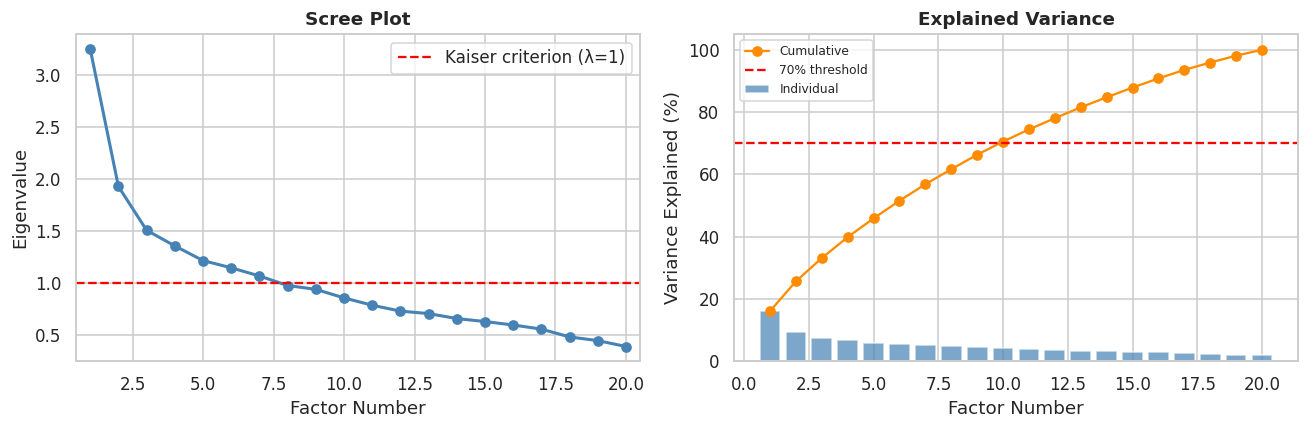


Factors with eigenvalue > 1: 7
Cumulative variance explained by 7 factors: 56.8%


In [16]:
# ── 5a. Scree Plot ────────────────────────────────────────────────────────────
pca_full = PCA()
pca_full.fit(X_scaled)
eigenvalues = pca_full.explained_variance_
explained   = pca_full.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, p+1), eigenvalues, 'o-', color='steelblue', linewidth=2)
axes[0].axhline(1, color='red', linestyle='--', label='Kaiser criterion (λ=1)')
axes[0].set_xlabel('Factor Number')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0.5, p + 0.5)

cum_exp = np.cumsum(explained)
axes[1].bar(range(1, p+1), explained, alpha=0.7, color='steelblue', label='Individual')
axes[1].plot(range(1, p+1), cum_exp, 'o-', color='darkorange', label='Cumulative')
axes[1].axhline(70, color='red', linestyle='--', label='70% threshold')
axes[1].set_xlabel('Factor Number')
axes[1].set_ylabel('Variance Explained (%)')
axes[1].set_title('Explained Variance', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Print components above λ=1
n_factors = (eigenvalues > 1).sum()
print(f'\nFactors with eigenvalue > 1: {n_factors}')
print(f'Cumulative variance explained by {n_factors} factors: {cum_exp[n_factors-1]:.1f}%')


=== Factor Loadings (7 factors retained) ===
(Values ≥ 0.40 in bold are primary loadings)

        F1     F2     F3     F4     F5     F6     F7
EA1  0.053  0.337 -0.344 -0.363  0.188  0.181 -0.113
EA2  0.067  0.415 -0.057  0.285 -0.012  0.155  0.110
EA3  0.047  0.359  0.233 -0.356 -0.310 -0.182 -0.164
EA4  0.084  0.397 -0.070 -0.079 -0.178 -0.108 -0.043
EA5  0.058  0.426  0.070 -0.028 -0.124  0.000  0.363
RA1  0.205  0.033  0.435 -0.242 -0.004 -0.207 -0.292
RA2  0.234 -0.195 -0.163 -0.390  0.078 -0.192 -0.114
RA3  0.244 -0.125  0.026  0.092 -0.394 -0.032 -0.349
RA4  0.264 -0.275 -0.108 -0.004  0.132 -0.355  0.097
RA5  0.302  0.014 -0.011  0.239 -0.127  0.277 -0.150
FT1  0.168  0.165  0.271  0.092  0.564 -0.103 -0.010
FT2  0.196  0.199 -0.192  0.036  0.365 -0.176 -0.151
FT3  0.256  0.038  0.169  0.066  0.154  0.444 -0.395
FT4  0.269  0.048 -0.409  0.059  0.043 -0.198 -0.048
FT5  0.219  0.099 -0.029  0.498  0.020 -0.241 -0.036
FL1  0.245 -0.115  0.090 -0.310  0.214  0.393  0.356
FL2  0.

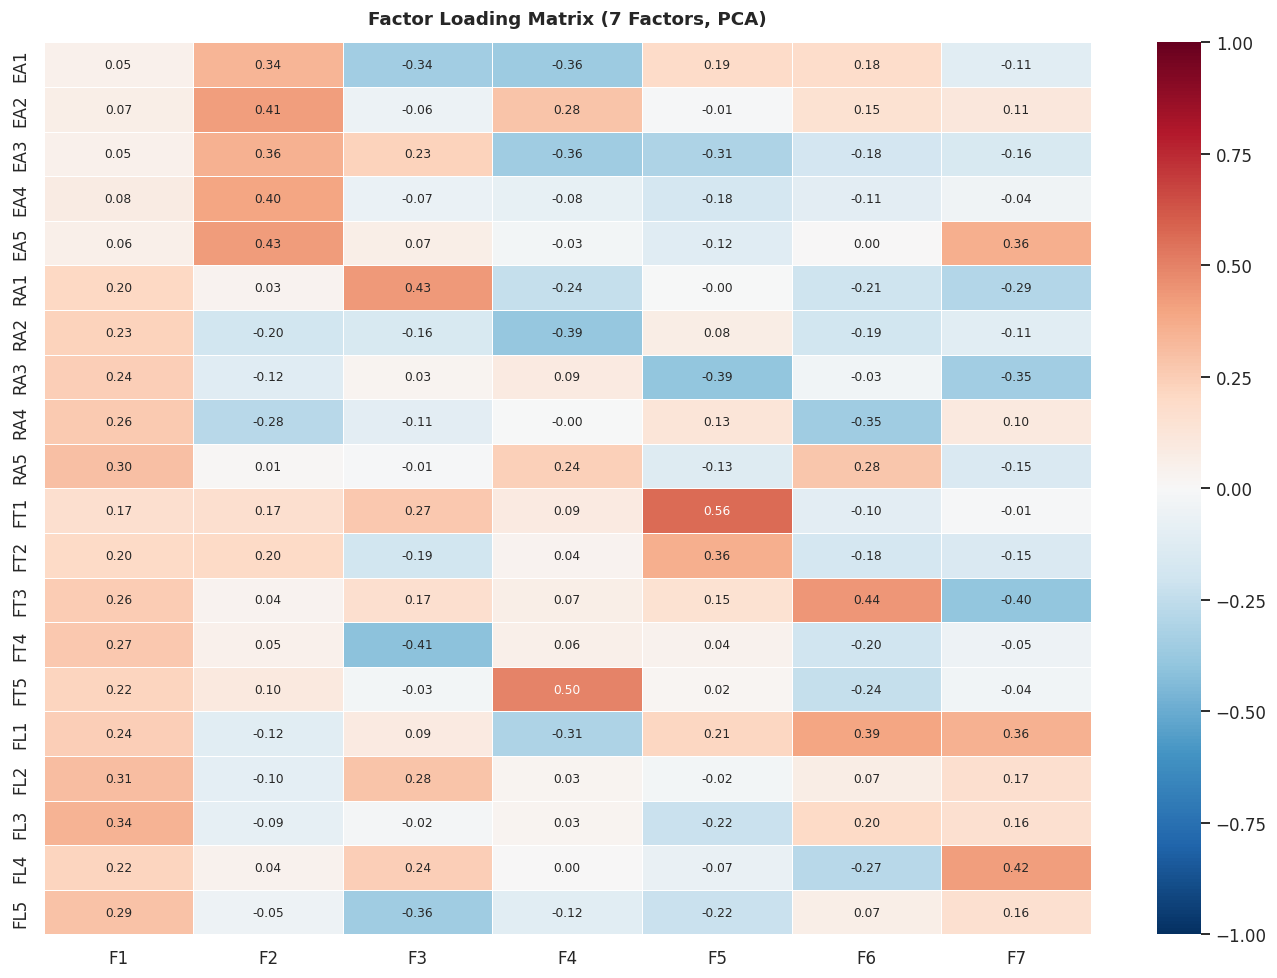

In [17]:
# ── 5b. Factor Loadings (retain n_factors) ────────────────────────────────────
pca_n = PCA(n_components=n_factors)
pca_n.fit(X_scaled)
loadings = pd.DataFrame(
    pca_n.components_.T,
    index=all_scale_items,
    columns=[f'F{i+1}' for i in range(n_factors)]
).round(3)

print(f'\n=== Factor Loadings ({n_factors} factors retained) ===')
print('(Values ≥ 0.40 in bold are primary loadings)\n')
print(loadings.to_string())

# Heatmap of loadings
fig, ax = plt.subplots(figsize=(n_factors*1.5 + 2, 9))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.4,
            ax=ax, annot_kws={'size': 8})
ax.set_title(f'Factor Loading Matrix ({n_factors} Factors, PCA)', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

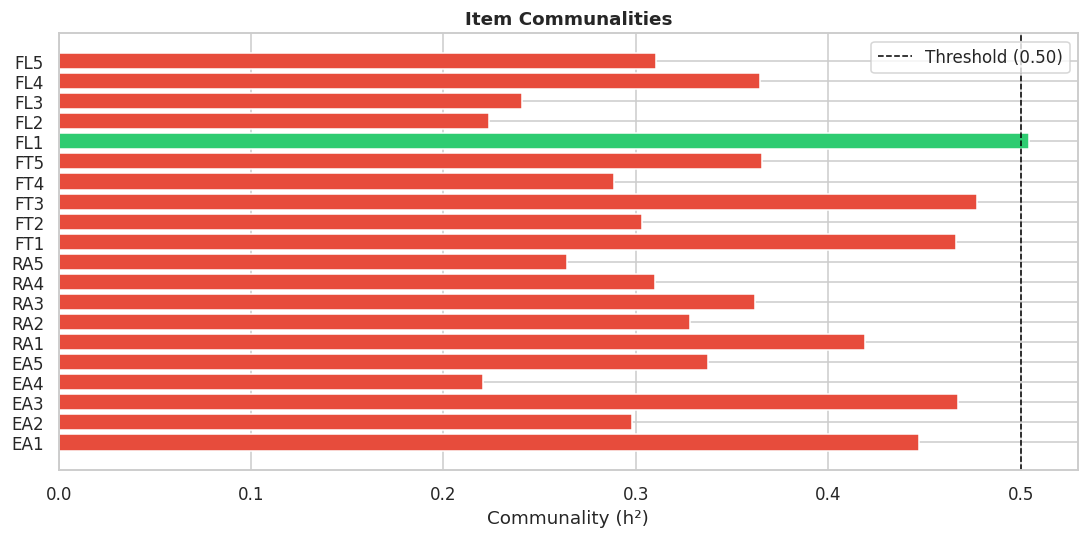

EA1    0.4471
EA2    0.2978
EA3    0.4676
EA4    0.2207
EA5    0.3376
RA1    0.4191
RA2    0.3280
RA3    0.3622
RA4    0.3100
RA5    0.2641
FT1    0.4665
FT2    0.3034
FT3    0.4771
FT4    0.2886
FT5    0.3658
FL1    0.5046
FL2    0.2237
FL3    0.2407
FL4    0.3647
FL5    0.3107


In [18]:
# ── 5c. Communalities ─────────────────────────────────────────────────────────
communalities = pd.Series(
    (pca_n.components_**2).sum(axis=0),
    index=all_scale_items, name='Communality'
).round(4)

fig, ax = plt.subplots(figsize=(10, 5))
colors_c = ['#2ecc71' if v >= 0.50 else '#e74c3c' for v in communalities]
ax.barh(communalities.index, communalities.values, color=colors_c, edgecolor='white')
ax.axvline(0.50, color='black', linestyle='--', linewidth=1, label='Threshold (0.50)')
ax.set_xlabel('Communality (h²)')
ax.set_title('Item Communalities', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print(communalities.to_string())

---
## 6. Summary Dashboard

In [19]:
summary = pd.DataFrame({
    'Construct': list(alpha_results.keys()),
    'Items': [5, 5, 5, 5],
    'Mean':  [df[EA_col].mean(), df[RA_col].mean(), df[FT_col].mean(), df[FL_col].mean()],
    'SD':    [df[EA_col].std(),  df[RA_col].std(),  df[FT_col].std(),  df[FL_col].std()],
    "Cronbach's α": list(alpha_results.values()),
    'Reliability': ['Acceptable' if v>=0.7 else 'Low' for v in alpha_results.values()],
}).round(3)
summary = summary.set_index('Construct')

print('\n' + '='*65)
print('             FINAL ANALYSIS SUMMARY')
print('='*65)
print(summary.to_string())
print('\n--- Regression Summary ---')
print(f'  Model 1 (EA+RA→ID):           R² = {r2_1:.4f}')
print(f'  Model 2 (+Financial Trust):   R² = {r2_2:.4f}')
print(f'  Model 3 (+Financial Literacy): R² = {r2_3:.4f}')
print(f'\n--- Factor Analysis ---')
print(f'  KMO = {kmo:.4f}  ({kmo_label})')
print(f'  Bartlett p = {p_bart:.2e}  (Significant)')
print(f'  Factors retained (λ>1): {n_factors}')
print(f'  Variance explained: {cum_exp[n_factors-1]:.1f}%')
print('='*65)


             FINAL ANALYSIS SUMMARY
                    Items   Mean     SD  Cronbach's α Reliability
Construct                                                        
Emotional Appeal        5  3.494  0.683         0.522         Low
Rational Appeal         5  3.649  0.668         0.504         Low
Financial Trust         5  3.490  0.614         0.483         Low
Financial Literacy      5  3.787  0.688         0.595         Low

--- Regression Summary ---
  Model 1 (EA+RA→ID):           R² = 0.0921
  Model 2 (+Financial Trust):   R² = 0.0923
  Model 3 (+Financial Literacy): R² = 0.1563

--- Factor Analysis ---
  KMO = -1.0017  (Mediocre)
  Bartlett p = 3.52e-16  (Significant)
  Factors retained (λ>1): 7
  Variance explained: 56.8%
